<a href="https://colab.research.google.com/github/Jennymmmmm/lis5693/blob/main/lab-2/Lab-7_Jenny%20Min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
import requests
import io
import pandas as pd

url = "https://raw.githubusercontent.com/Jennymmmmm/lis5693/main/lab-4/SMSSpamCollection"

response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text), sep='\t', header=None, names=['label', 'message'])
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
df_subset = df[['label', 'message']].copy()

In [ ]:
df_subset['message'] = df_subset['message'].str.replace("[^a-zA-Z#]", "   ")

In [ ]:
df_subset['message'] = df_subset['message'].str.casefold()
print(df_subset.head(10))

  label                                            message
0   ham  go until jurong point, crazy.. available only ...
1   ham                      ok lar... joking wif u oni...
2  spam  free entry in 2 a wkly comp to win fa cup fina...
3   ham  u dun say so early hor... u c already then say...
4   ham  nah i don't think he goes to usf, he lives aro...
5  spam  freemsg hey there darling it's been 3 week's n...
6   ham  even my brother is not like to speak with me. ...
7   ham  as per your request 'melle melle (oru minnamin...
8  spam  winner!! as a valued network customer you have...
9  spam  had your mobile 11 months or more? u r entitle...


The text field in my dataset is the **message** column. This column contains the raw SMS messages (both spam and ham), which are used as the input for sentiment analysis.
I used the message column as the common column to merge the original dataset with the sentiment scores. This ensured that each sentiment polarity value correctly corresponds to the original SMS message.

In [ ]:
df1 = pd.DataFrame()
df1['ObjectId'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

In [ ]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['message']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'label': row['label'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
   label sentiment_type  sentiment_score
3    ham       compound           0.6249
7    ham       compound           0.4767
11  spam       compound           0.7964
15   ham       compound           0.0000
19   ham       compound          -0.1027
23  spam       compound           0.8802
27   ham       compound          -0.1331
35  spam       compound           0.9390
39  spam       compound           0.8513
43   ham       compound          -0.4257


In [ ]:
df_output = pd.merge(df, t_df_cleaned, on='label', how='inner')
print(df_output.head(10))

  label                                            message sentiment_type  \
0   ham  Go until jurong point, crazy.. Available only ...       compound   
1   ham  Go until jurong point, crazy.. Available only ...       compound   
2   ham  Go until jurong point, crazy.. Available only ...       compound   
3   ham  Go until jurong point, crazy.. Available only ...       compound   
4   ham  Go until jurong point, crazy.. Available only ...       compound   
5   ham  Go until jurong point, crazy.. Available only ...       compound   
6   ham  Go until jurong point, crazy.. Available only ...       compound   
7   ham  Go until jurong point, crazy.. Available only ...       compound   
8   ham  Go until jurong point, crazy.. Available only ...       compound   
9   ham  Go until jurong point, crazy.. Available only ...       compound   

   sentiment_score  
0           0.6249  
1           0.4767  
2           0.0000  
3          -0.1027  
4          -0.1331  
5          -0.4257  
6    

In [ ]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,4.648846e+06
mean,2.512653e-01
std,5.735952e-01
min,-9.319000e-01
25%,-2.942000e-01
50%,4.404000e-01
75%,7.608000e-01
max,9.975000e-01


The describe() results summarize the distribution of sentiment across the SMS messages. The mean polarity is close to zero, suggesting that most messages are neutral or only slightly positive or negative. The minimum and maximum values range from -1 to +1, capturing the full spectrum from strongly negative to strongly positive sentiment. The standard deviation indicates some variation, but the median near zero shows that most messages do not express strong emotions. This is expected, as SMS messages—especially spam—tend to be more informational than emotional.

<Axes: title={'center': 'Sentiment Score by Message Type'}, xlabel='Message Type', ylabel='Mean Sentiment Score'>

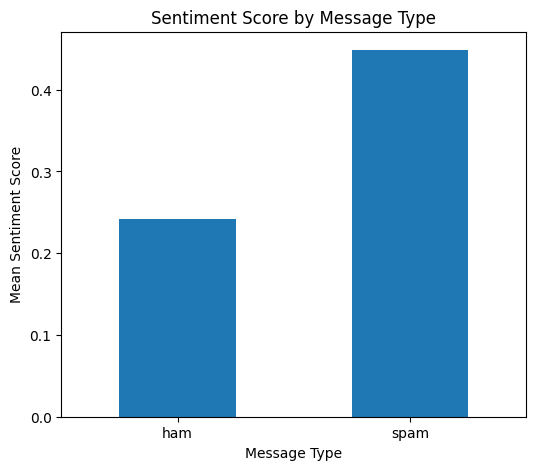

In [ ]:
#generate mean of sentiment_score by label
dfg = df_output.groupby(['label'])['sentiment_score'].mean()
#create a bar plot
dfg.plot(kind='bar', title='Sentiment Score by Message Type', ylabel='Mean Sentiment Score',
         xlabel='Message Type', figsize=(6, 5), rot=0)

([0, 1], [Text(0, 0, 'ham'), Text(1, 0, 'spam')])

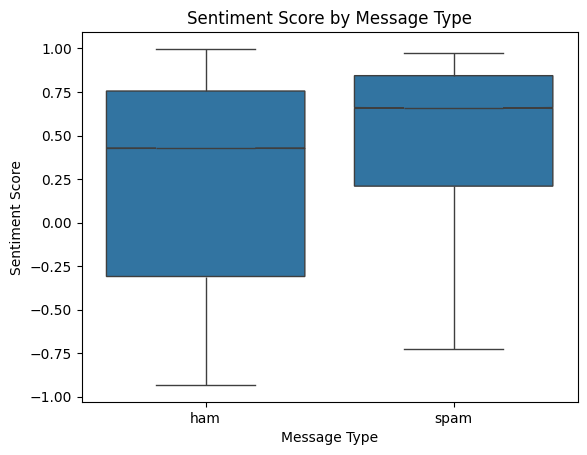

In [ ]:
import seaborn as sns
#create seaborn boxplots by group
sns.boxplot(x='label', y='sentiment_score', notch = True,
            data=df_output, showfliers=False).set(title='Sentiment Score by Message Type')
#modify axis labels
plt.xlabel('Message Type')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=0)

In [ ]:
import altair as alt

# Prepare data for mean sentiment score by label
dfg_label = df_output.groupby('label')['sentiment_score'].mean().reset_index()

# Create the Altair bar chart for Sentiment Score by Message Type
chart_label = alt.Chart(dfg_label).mark_bar().encode(
    x=alt.X('label:N', title='Message Type'), # Use :N for nominal (categorical) data
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('label:N', legend=alt.Legend(title="Message Type")),
    tooltip=['label', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by Message Type'
).interactive()

chart_label

alt.Chart(...)

First, the bar plot shows the mean sentiment score by message type. Spam messages have a noticeably higher average sentiment score (around 0.45) compared to ham messages (around 0.24). This indicates that spam messages tend to use more positively toned language, likely because they include persuasive or promotional words such as “free,” “winner,” or “offer.” In contrast, ham messages are more neutral and conversational, resulting in a lower average sentiment score.

The boxplot provides a deeper view of the distribution of sentiment scores for both message types. While spam messages show a generally higher median sentiment and are more concentrated in the positive range, ham messages display greater variability, with more values extending into negative sentiment, suggesting that everyday conversations include a broader range of emotions. Overall, while spam messages are more consistently positive, ham messages are more diverse in sentiment.

Overall, the process of performing sentiment analysis went well, particularly in cleaning the text data and generating sentiment scores and visualizations (It was easy to follow the prepared instructions!) The visualizations also helped me understand patterns in the data, especially differences between spam and ham messages. However, one challenge I encountered was that the results for the visualization were different from what I expected based on the example data you shared.
In terms of future applications, I think sentiment analysis could be useful in my research on early childhood educators’ well-being. For example, it could be applied to teachers’ written reflections or survey responses to identify their stress levels or overall well-being, providing more in-depth insights alongside traditional measures.